In [ ]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

In [ ]:
#tabel anova
def ANOVATAB(y,yhat,n,m):
  dfn = n
  dfd = m-n-1
  ybar = np.average(y)

  SSR = sum((yhat - ybar)**2)
  SSE = sum((y-yhat)**2)
  SST = sum((y-ybar)**2)
  MSR = SSR/dfn
  MSE = SSE/dfd

  Fs = MSR/MSE
  ks = 1-scipy.stats.f.cdf(Fs, dfn, dfd)
  data_table= {
    'SS': [SSR, SSE, SST],
    'df': [dfn, dfd,m-1] ,
    'MS': [MSR, MSE,'-'],
    'Fs': [Fs, '-','-'],
    'pval': [ks, '-','-']
  }

  return pd.DataFrame(data_table)

In [ ]:
#import data
data = pd.read_csv('Student_Performance.csv')

data

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
#menghapus baris yang sama
databaru = data.drop_duplicates()
databaru

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
databaru['Extracurricular Activities'] = databaru['Extracurricular Activities'].replace({'Yes' : 1, 'No' : 0})
databaru

<ipython-input-5-e063fb8aaa80>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  databaru['Extracurricular Activities'] = databaru['Extracurricular Activities'].replace({'Yes' : 1, 'No' : 0})


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
#menentukan data train dan data test
msk = np.random.rand(len(databaru)) < 0.8
train = databaru[msk]
test = databaru[~msk]
test.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
2,8,51,1,7,2,45.0
8,5,77,0,8,2,61.0
14,5,79,0,7,8,68.0
17,6,83,1,7,2,70.0
21,6,96,0,9,0,85.0


In [ ]:
#menentukan matriks A
m = len(train[['Performance Index']])
A = np.asanyarray(train[["Hours Studied", "Previous Scores"]])
print(A[0:5,:])

[[ 7 99]
 [ 4 82]
 [ 5 52]
 [ 7 75]
 [ 3 78]]


In [ ]:
#menambahkan vektor 1 pada kolom ke 0
A = np.insert(A,0, np.ones(m),1)
print (A[0:5,:])

[[ 1  7 99]
 [ 1  4 82]
 [ 1  5 52]
 [ 1  7 75]
 [ 1  3 78]]


In [ ]:
#menentukan vektor y
y = np.asanyarray(train[['Performance Index']])
print(y[0:5])

[[91.]
 [65.]
 [36.]
 [66.]
 [61.]]


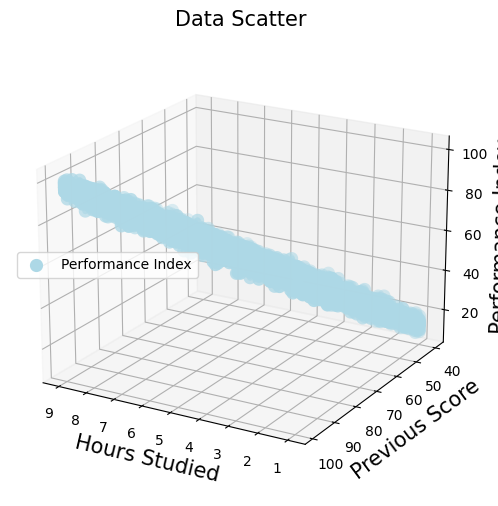

In [ ]:
#plot sebaran data yang akan dihampiri
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(20, 120)
ax.scatter(train[['Hours Studied']], train[['Previous Scores']], train[['Performance Index']],  color='lightblue',lw=5)
plt.legend(('Performance Index',), loc='center left')
ax.set_xlabel('Hours Studied',fontsize=15)
ax.set_ylabel('Previous Score',fontsize=15)
ax.set_zlabel('Performance Index', fontsize=15)
ax.set_title('Data Scatter', fontsize=15)
plt.show()

In [ ]:
#mencari koefisien C
C = np.linalg.inv(np.transpose(A)@A)@np.transpose(A)@y
print(C)

[[-29.90668932]
 [  2.86157683]
 [  1.01999811]]


In [ ]:
#nenentukan matriks  A  dan vektor  y  untuk data testing
m = len(test[['Performance Index']])
A = np.asanyarray(test[['Hours Studied','Previous Scores']])
A = np.insert(A,0, np.ones(m),1)
y = np.asanyarray(test[['Performance Index']])

In [ ]:
#mencari nilai hampiran yhat
yhat = A@C
print(yhat[0:5])

[[45.0058292 ]
 [62.94104969]
 [64.98104592]
 [71.92261521]
 [85.18259071]]


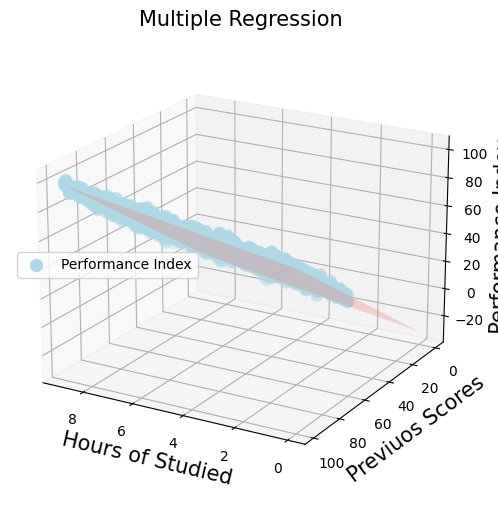

In [ ]:
#visualisasikan data testing dan daerah hampiran
def f(x1,x2):
  return C[0] + C[1]*x1 +C[2]*x2
xp = np.linspace(0,max(test['Hours Studied']),100)
yp = np.linspace(0,max(test['Previous Scores']),100)
X,Y = np.meshgrid(xp,yp)
Z = f(X,Y)
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(20, 120)
ax.scatter(test[['Hours Studied']], test[['Previous Scores']], test[['Performance Index']],  color='lightblue',lw=5)
ax.plot_surface(X, Y, Z, alpha=0.3, color='salmon', rstride=6, cstride=12)
plt.legend(('Performance Index',), loc='center left')
ax.set_xlabel('Hours of Studied',fontsize=15)
ax.set_ylabel('Previuos Scores',fontsize=15)
ax.set_zlabel('Performance Index', fontsize=15)
ax.set_title('Multiple Regression', fontsize=15)
plt.show()

In [ ]:
#menentukan TABEL ANOVA membuat keputusan Hypothesis dan melihat MSE
n=2
tabel = ANOVATAB(y,yhat,n,m)
tabel

,SS,df,MS,Fs,pval
0,[704176.1652716994],2,[352088.0826358497],[64268.64082828936],[1.1102230246251565e-16]
1,[10606.145068544285],1936,[5.4783807172232875],-,-
2,[708257.9566787014],1938,-,-,-


In [ ]:
#mengevaluasi R^2
R_s = 1 - tabel.SS[1]/tabel.SS[2]
print('Nilai R^2 adalah', R_s)

Nilai R^2 adalah [0.98502503]
